# 21 — Electrostriction: differentiating a response

Notebook 19 computed the **dielectric constant** — a second derivative of the energy with
respect to an electric field. Notebook 20 differentiated the *force* once more and got the
force constants. This one differentiates the **dielectric constant** once more, with
respect to a strain, and gets electrostriction: the quadratic electromechanical coupling
that every dielectric has.

Why that is the same thing as electrostriction is a thermodynamic identity, and it is the
method Tanner, Bousquet and Janolin
([arXiv:2012.03841](https://arxiv.org/abs/2012.03841)) established. Four coefficient
families describe the effect, and all four are derivatives of the susceptibility
$\chi$ or the stiffness $\eta = \chi^{-1}$ with respect to a mechanical variable:

$$ \varepsilon_0\,\frac{\partial \chi_{ij}}{\partial x_{kl}} = -2\,m_{ijkl},
\qquad
\frac{1}{\varepsilon_0}\frac{\partial \eta_{ij}}{\partial x_{kl}} = 2\,q_{ijkl} $$

with the stress-derivative pair $M$ and $Q$ following through the elastic compliance. The
alternative — optimising the cell under a finite $E$ or $D$ field and fitting a parabola —
caps the k-point density at whatever the band gap tolerates, tangles electrostriction with
non-linear piezoelectricity, and needs a constrained relaxation.

**So the quantity to compute is $d\varepsilon/dx$, and it is a *third* derivative of the
energy.** The trick that makes it one `jvp` rather than a sweep of re-converged
calculations is the 2n+1 theorem, in the one form it takes here: **the second-order energy
is stationary in the first-order wavefunctions**, so it can be differentiated with them
held fixed. That is notebook 09's envelope argument at the next order.

| | the published route | what happens here |
|---|---|---|
| $d\varepsilon/dx$ | five re-converged SCF + DFPT runs per strain | one `jvp` of the second-order energy |
| the strain perturbation | Abinit's metric-tensor formulation, derived by hand | one `jvp` through `at_strain`, which was already in reduced coordinates |
| $d\psi/dx$, $d\rho/dx$ | — | a Sternheimer solve, as for a phonon |
| the elastic constants | a separate calculation | one more `jvp` of the stress, reusing the same response |

Against a central difference of $\varepsilon$ over re-converged strained cells — the
published route, run here as the reference — the three independent components of
$d\varepsilon/dx$ agree to **2 × 10⁻⁴**, which is the finite difference's own floor.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.response import electrostriction
from pypresso.scf import Calculation, run_scf
from pypresso.system import build_system

CASES = Path("../tests/data/qe")
PSEUDO = Path("../tests/data/pseudo")

# An **unshifted** k-grid with `nosym`. The grid has to be unshifted -- a shifted one is
# not closed under the point group, so it can neither be run whole nor be symmetrised from
# its wedge. `nosym` is now a choice rather than a requirement: the object differentiated
# here carries a field label and a strain label at once, and P36's rank-4 average
# (`symmatrix3` generalised) completes such a sum on the wedge, agreeing with this run to
# 7.9e-14. The elastic constants below still need the whole grid, for a different reason --
# their functional builds its own density and symmetrises it as a scalar.
system = build_system(read_pw_input(CASES / "si-electrostriction.in"))
pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
calculation = Calculation(system, pseudos)
scf = run_scf(system, pseudos, calculation=calculation, conv_thr=1e-12)

print(f"silicon, {len(system.kpoints.weights)} k-points, "
      f"{calculation.basis.planewaves.npwx} plane waves")
print(f"total energy   {scf.total_energy:.9f} Ry")

silicon, 8 k-points, 190 plane waves
total energy   -15.614354628 Ry


## 1. One call

Inside it: a self-consistent field response (notebook 19), a self-consistent **strain**
response — the same `solve_linter` loop with six perturbations instead of three — one
further Sternheimer solve per direction for the position operator's own strain derivative,
and then six `jvp`s of the second-order energy.

In [2]:
result = electrostriction(calculation, scf)

print(f"epsilon_infinity      {np.trace(result.epsilon) / 3:.6f}")
print(f"strain response       {len(result.strain.history)} iterations, "
      f"{result.strain.average_iterations:.0f} CG steps per band per solve")

epsilon_infinity      56.292875
strain response       18 iterations, 22 CG steps per band per solve


## 2. $d\chi/dx$, and the check that nothing imposed it

The k-grid is closed under the point group and **no average is applied anywhere** in this
phase. So the components a cubic crystal forbids are a measurement rather than a
construction: a wrong index convention anywhere in the chain would survive every value
check and show up here. Two of them did, during development — a transposed pair of band
indices in the Lagrange multiplier, worth 11% of the scale, and the same thing in the
position operator's equation.

In [3]:
VOIGT = [(0, 0), (1, 1), (2, 2), (1, 2), (0, 2), (0, 1)]
LABELS = ["11", "22", "33", "23", "13", "12"]

table = np.array([[result.dchi_dstrain[i][j][k][l] for (k, l) in VOIGT]
                  for (i, j) in VOIGT])

print("d(chi_ij)/dx_kl, Voigt rows x columns")
print("      " + "".join(f"{c:>9}" for c in LABELS))
for label, row in zip(LABELS, table):
    print(f"  {label}  " + "".join(f"{v:9.4f}" for v in row))

forbidden = np.concatenate([table[3:, :3].ravel(), table[:3, 3:].ravel()])
print(f"\nlargest component cubic symmetry forbids: "
      f"{np.abs(forbidden).max() / np.abs(table).max():.1e} of the scale")

d(chi_ij)/dx_kl, Voigt rows x columns
             11       22       33       23       13       12
  11   108.1081   8.1021   8.1021  -0.0000   0.0000   0.0000
  22     8.1021 108.1081   8.1021  -0.0000   0.0000   0.0000
  33     8.1021   8.1021 108.1081  -0.0000  -0.0000   0.0000
  23     0.0000  -0.0000  -0.0000 197.0154   0.0000  -0.0000
  13     0.0000  -0.0000   0.0000  -0.0000 197.0154  -0.0000
  12     0.0000   0.0000  -0.0000   0.0000  -0.0000 197.0154

largest component cubic symmetry forbids: 3.1e-14 of the scale


## 3. The derivative *is* the slope

The figure is the whole claim in one picture. The points are $\varepsilon$ computed the
published way — an SCF and a dielectric response at each of five strained cells, measured
once offline and quoted here rather than re-run — and the lines are the tangents from the
single `jvp` above. An axial strain along $x$ pulls $\varepsilon_{11}$ up thirteen times
harder than $\varepsilon_{22}$, and both slopes come out of the same call.

central difference of the sweep   108.1021
one jvp                           108.1081
relative difference               5.5e-05


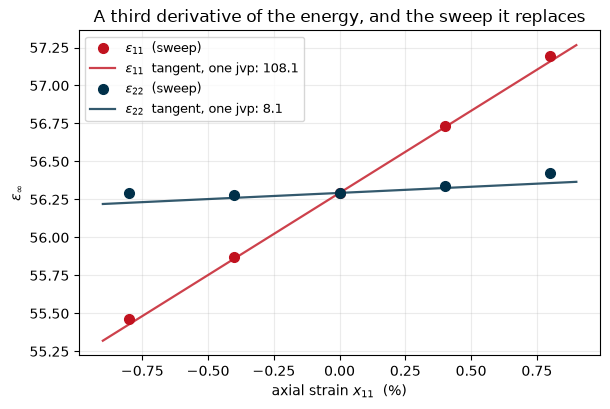

In [4]:
# Measured offline: five re-converged SCF + dielectric calculations, ~2 minutes each.
SWEEP = np.array([-0.008, -0.004, 0.0, 0.004, 0.008])
EPS_11 = np.array([55.462182, 55.868947, 56.292855, 56.733764, 57.191543])
EPS_22 = np.array([56.289746, 56.276022, 56.292855, 56.341161, 56.421977])

eps0 = float(np.trace(result.epsilon) / 3)
slope_11 = result.depsilon_dstrain[0, 0, 0, 0]
slope_22 = result.depsilon_dstrain[1, 1, 0, 0]

fig, ax = plt.subplots(figsize=(6.2, 4.2))
fine = np.linspace(-0.009, 0.009, 2)
for points, slope, colour, label in (
    (EPS_11, slope_11, "#c1121f", r"$\varepsilon_{11}$"),
    (EPS_22, slope_22, "#003049", r"$\varepsilon_{22}$"),
):
    ax.plot(SWEEP * 100, points, "o", color=colour, ms=7, zorder=3,
            label=f"{label}  (sweep)")
    ax.plot(fine * 100, eps0 + slope * fine, "-", color=colour, lw=1.6, alpha=0.8,
            label=f"{label}  tangent, one jvp: {slope:.1f}")
ax.set_xlabel("axial strain $x_{11}$  (%)")
ax.set_ylabel(r"$\varepsilon_\infty$")
ax.set_title("A third derivative of the energy, and the sweep it replaces")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()

central = (EPS_11[3] - EPS_11[1]) / (SWEEP[3] - SWEEP[1])
print(f"central difference of the sweep   {central:.4f}")
print(f"one jvp                           {slope_11:.4f}")
print(f"relative difference               "
      f"{abs(slope_11 - central) / abs(central):.1e}")

## 4. The number a laboratory has measured

$d\varepsilon/dx$ *is* the elasto-optic (photoelastic) tensor, up to an inversion:
$\Delta(\varepsilon^{-1})_{ij} = p_{ijkl}\,x_{kl}$, so
$p = -\varepsilon^{-1}\,(d\varepsilon/dx)\,\varepsilon^{-1}$ — pure algebra on what the
call already returned, and the one quantity here with a direct measurement to sit against.

The symmetry story decides which components are a *fair* comparison. In the diamond
structure no internal atomic displacement is compatible with a tetragonal strain, so
$p_{11}$ and $p_{12}$ have no ionic contribution and the clamped-ion calculation is the
whole answer. $p_{44}$ carries a Kleinman internal-displacement term that is **not**
computed here, and is shown greyed out for that reason.

In [5]:
p = result.photoelastic_voigt
BIEGELSEN = {"p11": -0.094, "p12": +0.017, "p44": -0.051}   # PRL 32, 1196 (1974)

print(f"{'':6}{'pypresso':>12}{'experiment':>13}   comparable?")
for name, ours, measured in (
    ("p11", p[0, 0], BIEGELSEN["p11"]),
    ("p12", p[0, 1], BIEGELSEN["p12"]),
    ("p44", p[3, 3], BIEGELSEN["p44"]),
):
    note = "yes" if name != "p44" else "no -- needs the ionic term"
    print(f"{name:6}{ours:12.4f}{measured:13.4f}   {note}")

          pypresso   experiment   comparable?
p11        -0.0341      -0.0940   yes
p12        -0.0026       0.0170   yes
p44        -0.0622      -0.0510   no -- needs the ionic term


`p11` comes out with the right sign and within a factor of three; **`p12` does not** —
it is $-0.003$ here against $+0.017$ measured, sign included. That is the k-sample, not the
derivative: the same numbers come out of a central difference of $\varepsilon$ over
re-converged cells, which shares no machinery with the analytic route, and this grid gives
$\varepsilon_\infty = 56$ where silicon's is 13.8. The closed-grid requirement is what
keeps the sample small — an unshifted Monkhorst-Pack grid is the only kind this phase
accepts, and converging $\varepsilon_\infty$ on one takes far more k-points than a shifted
grid needs. `PLAN.md`'s P26 section carries the convergence study.

**So read this table as a check on the units and the algebra, not on silicon.** What the
notebook establishes about the *method* is §3's number: the analytic third derivative
reproduces the sweep it replaces to $5\times10^{-5}$.

## 5. The four coefficient families

`m` and `q` come straight from $d\chi/dx$. `M` and `Q` — the ones that give a *strain*,
which is what experiment usually quotes — need the elastic compliance, and with the strain
response already in hand the elastic constants are one more `jvp` of the stress: the same
construction as the force constants, with the cell in place of the atoms.

In [6]:
print("elastic constants, clamped-ion (GPa)")
print(f"  C11 = {result.elastic.voigt[0, 0]:8.1f}      C12 = {result.elastic.voigt[0, 1]:8.1f}"
      f"      C44 = {result.elastic.voigt[3, 3]:8.1f}")
print(f"  B   = {result.elastic.bulk_modulus:8.1f}      "
      f"(silicon, measured: C11 165.7, C12 63.9, B 97.9)")

m_h, q_h = result.hydrostatic
big_m_h, big_q_h = result.hydrostatic_Mq
print("\nhydrostatic electrostriction coefficients")
print(f"  m_h = {m_h:10.1f} pN/V^2        q_h = {q_h:10.3f} GN m^2/C^2")
print(f"  M_h = {big_m_h:10.1f} pm^2/V^2      Q_h = {big_q_h:10.4f} m^4/C^2")

elastic constants, clamped-ion (GPa)
  C11 =    209.4      C12 =     68.0      C44 =    134.0
  B   =    115.1      (silicon, measured: C11 165.7, C12 63.9, B 97.9)

hydrostatic electrostriction coefficients
  m_h =     -550.3 pN/V^2        q_h =     -2.296 GN m^2/C^2
  M_h =     1593.7 pm^2/V^2      Q_h =     0.0066 m^4/C^2


**The elastic constants are clamped-ion, and that is the caveat to read them with.**
The ions are held at their crystallographic positions. For `C11`, `C12`, `p11` and `p12` in
the diamond structure that is the complete answer by symmetry — no internal displacement is
compatible with a tetragonal strain. For `C44` and `p44` it is not, and the missing internal
relaxation is what would bring `C44` down toward the measured 79.6 GPa.

`C11` here reproduces a five-point second difference of the SCF energy, at the same frozen
plane-wave sphere, to five significant figures — which is the check that matters, since the
gap to the measured 165.7 GPa is the functional, the pseudopotential and the cutoff rather
than the derivative.

## 6. How it works, in one idea

Write the second-order energy as a functional of the field response $u$, the ground state,
the density and the position operator $b = P_c\,r|\psi\rangle$:

$$ F_{ij}[x;\psi,\rho,b,u] = \sum_{kn} w\Big[\langle u_i|H(x)|u_j\rangle
   - \Lambda_{mn}\langle u_{i,n}|u_{j,m}\rangle + 2\,\mathrm{Re}\,\langle u_i|P_c b_j\rangle\Big]
   + \tfrac12\!\int\! d\rho_i\,K(x)\,d\rho_j $$

Its stationary point in $u$ is exactly the Sternheimer solution notebook 19 already
computes, and its stationary *value* is the expression `dielec.f90` assembles. So

$$ \frac{d\varepsilon_{ij}}{dx_{kl}} = \mathrm{jvp}\big(F_{ij}\big)
   \big(x,\psi,\rho,b;\ e_{kl},\ d\psi/dx,\ d\rho/dx,\ db/dx\big) $$

**with no tangent for $u$ at all.** That is the whole saving.

**And the trap of the phase is in that sentence.** $u$ is frozen — but the space it is
*constrained* to live in is not. The Sternheimer solution must be orthogonal to the
occupied manifold, and that manifold moves with the strain, so the variable of the
functional is $P_c(\psi)\,u$ and never the stored array. Writing $u$ changes no value
($P_c u = u$ where everything is evaluated) and destroys the stationarity the whole
construction rests on. It is worth **2%** of $d\varepsilon/dx$ on silicon, and it survived
the value identity against `dielec.f90`, the cubic-form check of §2, *and* a
finite-difference check of each of the four tangents separately. What found it was
splitting the disagreement in two: the `jvp` against a difference of $F$ at frozen $u$
(which agreed to $10^{-4}$), and that against the true $\varepsilon$ (which did not).

---

**Where to read more.** `PLAN.md` §3, phase **P26** — the derivation, the four validation
tables, the index-order traps and the cutoff study. The tests are
`tests/regression/test_electrostriction.py`; the code is
`pypresso/response/strain.py`, `elastic.py` and `electrostriction.py`. The method is
[Tanner, Bousquet & Janolin, *Small* **17**, 2103419 (2021)](https://arxiv.org/abs/2012.03841);
the strain perturbation's reference formulation is
[Hamann, Wu, Rabe & Vanderbilt, PRB **71**, 035117 (2005)](https://arxiv.org/abs/cond-mat/0409269).